# Scotia Snowboard: how many boards to produce?

Scotia produces snowboards before the season, not knowing how demand will turn out. Each board costs $c = 200$ to make and sells for $p = 480$; any unsold board is discounted to a salvage value $s = 80$. This is a **newsvendor problem**: produce too many and the surplus sells at a loss; produce too few and we forgo high-margin sales.

Demand depends on the winter weather. With probability $\tfrac{1}{3}$ the season is good and demand is $\mathcal{N}(100{,}000,\ 35{,}000^2)$; with probability $\tfrac{2}{3}$ it is poor and demand is $\mathcal{N}(75{,}000,\ 22{,}500^2)$. Production must be chosen *before* the weather is known, so the relevant demand is this two-state mixture.

We find the profit-maximizing production level by Monte Carlo, show that simply producing the *expected* demand leaves money on the table, and confirm the answer with the newsvendor **critical-fractile rule**: order up to the $\lambda = \tfrac{p - c}{p - s}$ quantile of demand.

## Setup

Imports, plot formatting helpers, and a fixed random seed so the simulated demand draws are reproducible.

In [1]:
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
np.random.seed(666)

## Optimal production by simulation

We draw 10,000 demand scenarios from the weather mixture, then search over production levels for the one that maximizes mean profit. For comparison, we also evaluate the naive policy of producing exactly the expected demand — which, because profit is asymmetric in over- vs. under-production, earns less than the optimum.

In [3]:
production_cost  = 200
selling_price    = 480
discounted_price = 80

# Weather mixture: P(good, high demand) = 1/3, P(poor, low demand) = 2/3
demand_prob = [1/3, 2/3]
demand_distributions = [
    {"mean": 100_000, "std_dev": 35_000},
    {"mean":  75_000, "std_dev": 22_500},
]

def calculate_profit(produced, demand, production_cost, selling_price, discounted_price):
    sold   = min(produced, demand)
    unsold = max(0, produced - demand)
    revenue = sold * selling_price + unsold * discounted_price
    cost    = produced * production_cost
    return revenue - cost

def sample_demand_and_weather(demand_prob, demand_distributions):
    weather = np.random.choice(len(demand_prob), p=demand_prob)
    distribution = demand_distributions[weather]
    demand = np.random.normal(distribution["mean"], distribution["std_dev"])
    return round(demand), weather

# Draw scenarios once so every production level is evaluated on the same realizations
n_simulations = 10_000
demand_scenarios = []
weather_scenarios = []
for _ in range(n_simulations):
    demand, weather = sample_demand_and_weather(demand_prob, demand_distributions)
    demand_scenarios.append(demand)
    weather_scenarios.append(weather)

def monte_carlo_expected_profit(produced, demand_scenarios, production_cost, selling_price, discounted_price):
    profits = [calculate_profit(produced, demand, production_cost, selling_price, discounted_price)
               for demand in demand_scenarios]
    return np.mean(profits)

def objective(produced):
    return -monte_carlo_expected_profit(produced, demand_scenarios, production_cost, selling_price, discounted_price)

result = minimize_scalar(objective, bounds=(0, 100_000), method='bounded')
optimal_production = round(result.x)
max_profit = round(-result.fun)

print("Optimal number of snowboards to produce:", optimal_production)
print("Expected profit:", max_profit)

# Naive benchmark: produce exactly the (simulated) expected demand
expected_demand = round(np.mean(demand_scenarios))
expected_profits = monte_carlo_expected_profit(expected_demand, demand_scenarios, production_cost, selling_price, discounted_price)

print("Expected demand:", expected_demand)
print("Expected profits when producing exactly the expected demand:", round(expected_profits))

Optimal number of snowboards to produce: 95999
Expected profit: 19157489
Expected demand: 83274
Expected profits when producing exactly the expected demand: 18736792


## Profit across production levels

Sweeping production from 0 to 150,000 shows the full profit distribution (boxplots) and expected profit (green line). The peak sits at the optimal level found above (red dashed line).

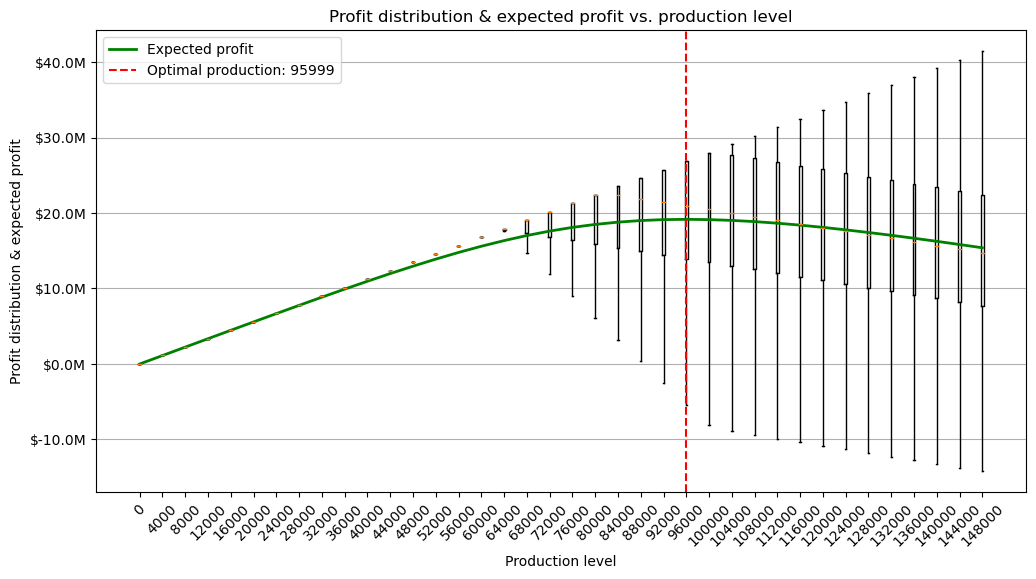

In [4]:
def millions_formatter(x, pos):
    return f"${x * 1e-6:.1f}M"

production_levels = list(range(0, 150_001, 4_000))
profit_distributions = []
expected_profits = []

for produced in production_levels:
    profits = [calculate_profit(produced, demand, production_cost, selling_price, discounted_price) for demand in demand_scenarios]
    profit_distributions.append(profits)
    expected_profits.append(np.mean(profits))

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(profit_distributions, positions=production_levels, widths=500, showfliers=False)
ax.plot(production_levels, expected_profits, color='g', linewidth=2, label='Expected profit')

ax.set_xticks(production_levels)
ax.set_xticklabels(production_levels, rotation=45)
ax.set_xlabel("Production level")
ax.set_ylabel("Profit distribution & expected profit")
ax.set_title("Profit distribution & expected profit vs. production level")
ax.axvline(x=optimal_production, color='r', linestyle='--', label=f'Optimal production: {optimal_production}')
ax.legend()
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax.grid(axis='y')
plt.show()

## Check against the newsvendor critical fractile

The newsvendor rule says the optimal order is the $\lambda$ quantile of demand, where $\lambda = \dfrac{p - c}{p - s}$ is the critical fractile — the ratio of the underage cost (lost margin on a board we could have sold) to the total over/underage cost. Here $\lambda = \dfrac{480 - 200}{480 - 80} = 70\%$, so the optimal production is the 70th percentile of demand. It should match the simulated optimum above.

In [5]:
# Critical fractile lambda = (p - c) / (p - s), as a percentile
lambda_ = (selling_price - production_cost) / (selling_price - discounted_price) * 100
print(lambda_)

70.0


In [6]:
# The lambda-th percentile of demand -- compare to the simulated optimum
np.percentile(np.array(demand_scenarios), lambda_)

95997.2